In [7]:
%pip install pandas numpy scikit-learn matplotlib seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached tzdata-2026.2-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.9 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.9 MB 1.3 MB/s eta 0:00:08
   --- ------------------------------------ 0.8/9.9 MB 1.2 MB/s eta 0:00:08
   ---- ----------------------------------- 1.0/9.9 MB 1.3 MB/s eta 0:00:07
   ---- ------------------------


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


# Freshlync Sales Prediction: Baseline Model

1. Load data
2. Preprocess
3. Train model
4. Evaluate

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
import warnings
warnings.filterwarnings('ignore')

In [10]:
df = pd.read_csv('../data/sample_orders.csv')
df.head()

,date,product_name,category,quantity_sold,price,day_of_week,is_holiday,weather_condition
0,2023-01-01,Tomato,vegetable,122,564.17,Sunday,0,sunny
1,2023-01-01,Seer Fish,fish,96,1625.21,Sunday,1,cloudy
2,2023-01-02,Pork,meat,127,855.60,Monday,0,cloudy
3,2023-01-02,Potato,vegetable,114,943.85,Monday,0,rainy
4,2023-01-03,Beans,vegetable,106,839.25,Tuesday,0,rainy


In [11]:
X = df[['product_name', 'category', 'price', 'day_of_week', 'is_holiday', 'weather_condition']]
y = df['quantity_sold']

categorical_cols = ['product_name', 'category', 'day_of_week', 'weather_condition']
preprocessor = ColumnTransformer(transformers=[('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_cols)], remainder='passthrough')
X_processed = preprocessor.fit_transform(X)


In [12]:
X_train, X_test, y_train, y_test = train_test_split(X_processed, y, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(X_train, y_train)
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)


In [13]:
mse_train = mean_squared_error(y_train, y_pred_train)
rmse_train = np.sqrt(mse_train)
mse_test = mean_squared_error(y_test, y_pred_test)
rmse_test = np.sqrt(mse_test)
print(f'Train RMSE: {rmse_train:.2f}')
print(f'Test RMSE: {rmse_test:.2f}')

Train RMSE: 33.63
Test RMSE: 35.94


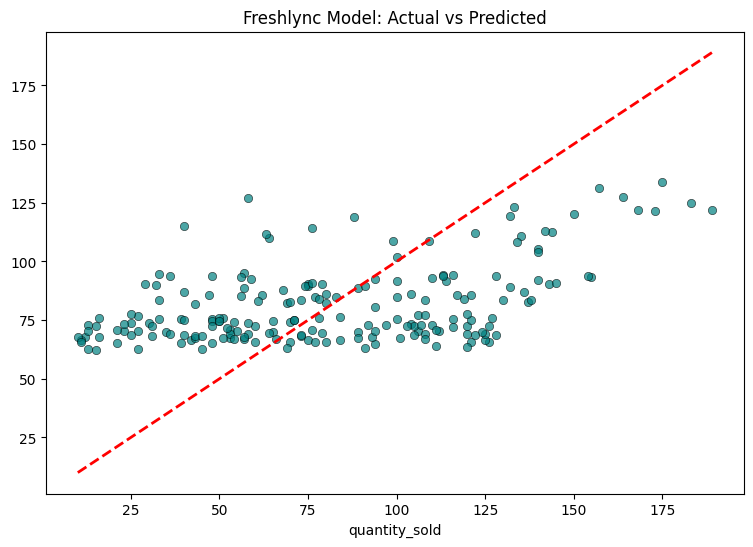

In [14]:
plt.figure(figsize=(9, 6))
sns.scatterplot(x=y_test, y=y_pred_test, alpha=0.7, color='teal', edgecolor='black')
min_val = min(y_test.min(), y_pred_test.min())
max_val = max(y_test.max(), y_pred_test.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', lw=2)
plt.title('Freshlync Model: Actual vs Predicted')
plt.show()

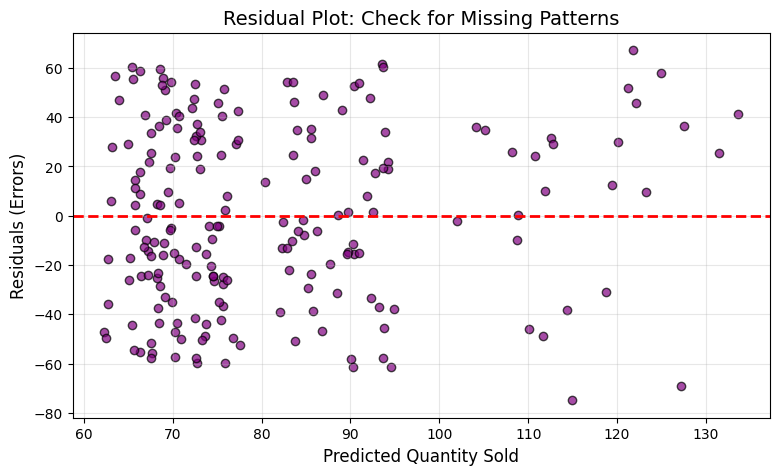

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

residuals = y_test - y_pred_test

plt.figure(figsize=(9, 5))
plt.axhline(y=0, color='red', linestyle='--', lw=2)
plt.scatter(y_pred_test, residuals, alpha=0.7, color='purple', edgecolor='black')

plt.title('Residual Plot: Check for Missing Patterns', fontsize=14)
plt.xlabel('Predicted Quantity Sold', fontsize=12)
plt.ylabel('Residuals (Errors)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

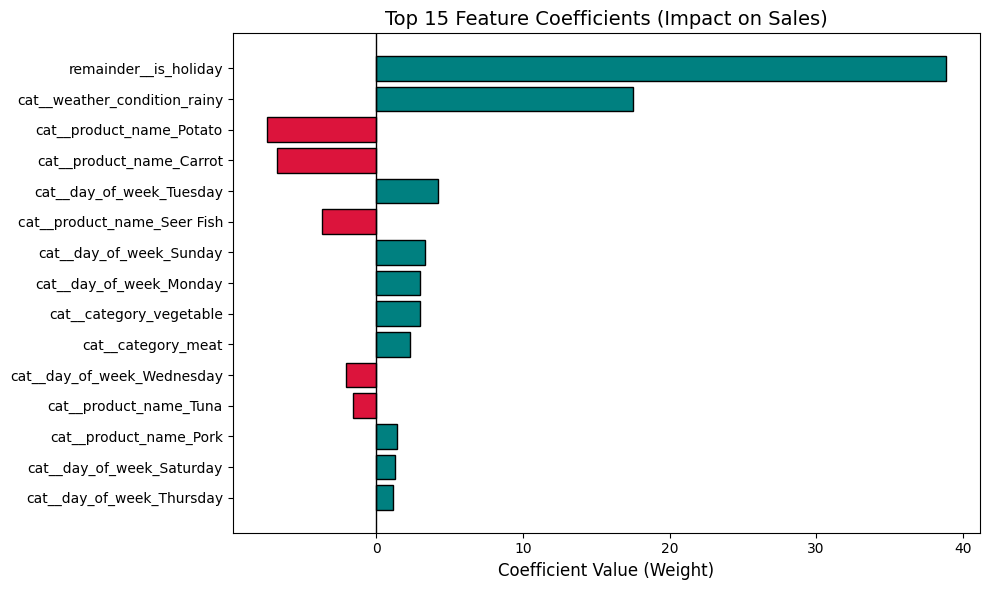

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

# Extract feature names from the preprocessor
feature_names = preprocessor.get_feature_names_out()

# Extract coefficients from the model
coefficients = model.coef_

# Create a dataframe for easy plotting
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
}).sort_values(by='Coefficient', key=abs, ascending=False)

# Plot the top 15 most influential features
plt.figure(figsize=(10, 6))
colors = ['teal' if c > 0 else 'crimson' for c in coef_df['Coefficient'].head(15)]
plt.barh(coef_df['Feature'].head(15), coef_df['Coefficient'].head(15), color=colors, edgecolor='black')

plt.axvline(x=0, color='black', linestyle='-', lw=1)
plt.title('Top 15 Feature Coefficients (Impact on Sales)', fontsize=14)
plt.xlabel('Coefficient Value (Weight)', fontsize=12)
plt.gca().invert_yaxis()  # Highest impact at the top
plt.tight_layout()
plt.show()

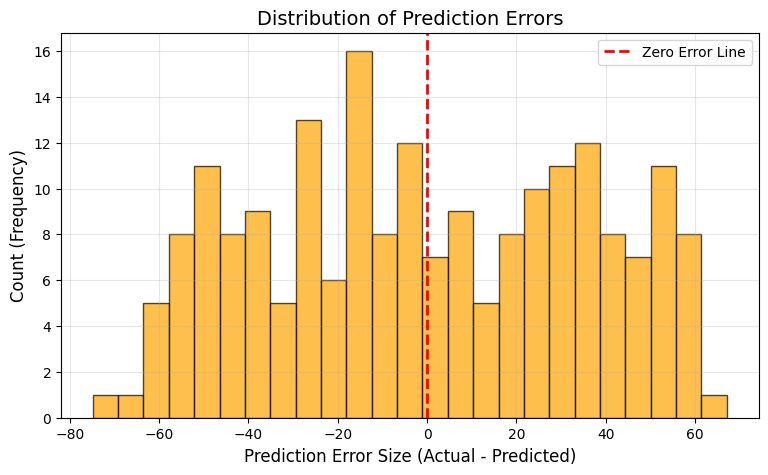

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(9, 5))
# Plotting the distribution of errors
plt.hist(residuals, bins=25, color='orange', edgecolor='black', alpha=0.7)

plt.axvline(x=0, color='red', linestyle='--', lw=2, label='Zero Error Line')
plt.title('Distribution of Prediction Errors', fontsize=14)
plt.xlabel('Prediction Error Size (Actual - Predicted)', fontsize=12)
plt.ylabel('Count (Frequency)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()